### IMPORTAÇÃO DAS BIBLIOTECAS ###

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

# configurações visuais
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

### CARREGAMENTO DA BASE ###

In [4]:
df = pd.read_csv('desafio_nps_fase_1.csv')

print('Shape da base:')
print(df.shape)

print('\nPrimeiras linhas:')
display(df.head())


Shape da base:
(2500, 19)

Primeiras linhas:


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### INFORMAÇÕES GERAIS DA BASE ###

In [5]:
print('\nInformações da base:')
print(df.info())

print('\nEstatísticas descritivas:')
display(df.describe())



Informações da base:
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-n

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


### VALORES NULOS ###

In [6]:
print('\nValores nulos:')
display(df.isnull().sum())


Valores nulos:


customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

### DUPLICADOS ###

In [7]:
print('\nDuplicados:')
print(df.duplicated().sum())


Duplicados:
0


### CLASSIFICAÇÃO DO NPS ###

In [8]:
def classify_nps(score):
    
    if score <= 6:
        return 'Detrator'
    
    elif score <= 8:
        return 'Neutro'
    
    else:
        return 'Promotor'


df['nps_classification'] = df['nps_score'].apply(classify_nps)

display(df[['nps_score', 'nps_classification']].head())

,nps_score,nps_classification
0,6.9,Neutro
1,2.4,Detrator
2,4.8,Detrator
3,5.9,Detrator
4,6.1,Neutro


### DISTRIBUIÇÃO DAS CLASSES NPS ###


Distribuição das classes:


nps_classification
Detrator    74.04
Neutro      17.92
Promotor     8.04
Name: proportion, dtype: float64

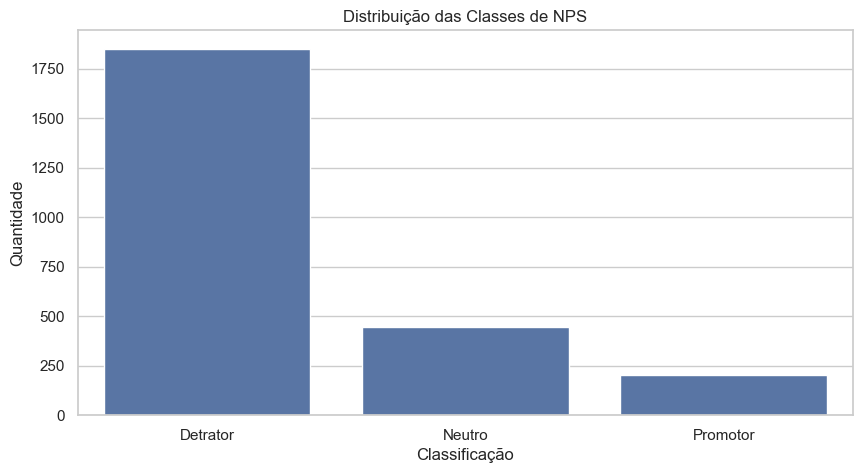

In [9]:
nps_distribution = (
    df['nps_classification']
    .value_counts(normalize=True) * 100
)

print('\nDistribuição das classes:')
display(nps_distribution)

# gráfico

sns.countplot(
    data=df,
    x='nps_classification',
    order=['Detrator', 'Neutro', 'Promotor']
)

plt.title('Distribuição das Classes de NPS')
plt.xlabel('Classificação')
plt.ylabel('Quantidade')

plt.show()

### NPS MÉDIO ###

In [10]:
nps_mean = df['nps_score'].mean()

print('\nNPS médio:')
print(round(nps_mean, 2))



NPS médio:
4.38


### DISTRIBUIÇÃO DO NPS ###

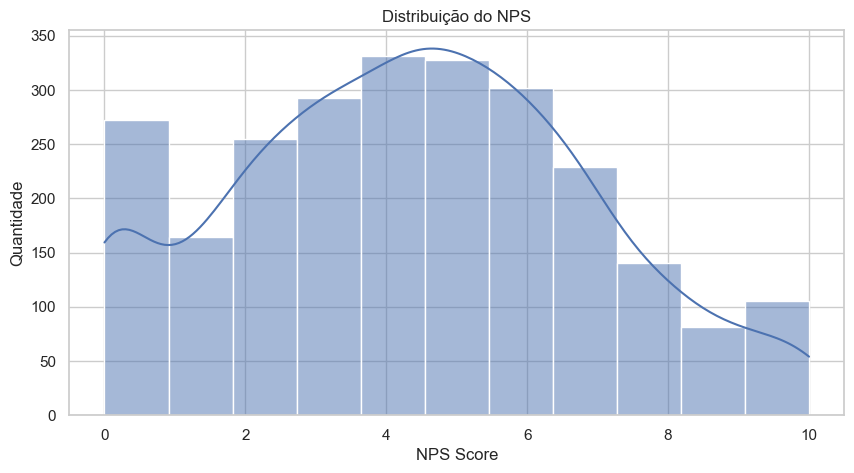

In [11]:
sns.histplot(
    df['nps_score'],
    bins=11,
    kde=True
)

plt.title('Distribuição do NPS')
plt.xlabel('NPS Score')
plt.ylabel('Quantidade')

plt.show()

### ANÁLISE UNIVARIADA — VARIÁVEIS NUMÉRICAS ###

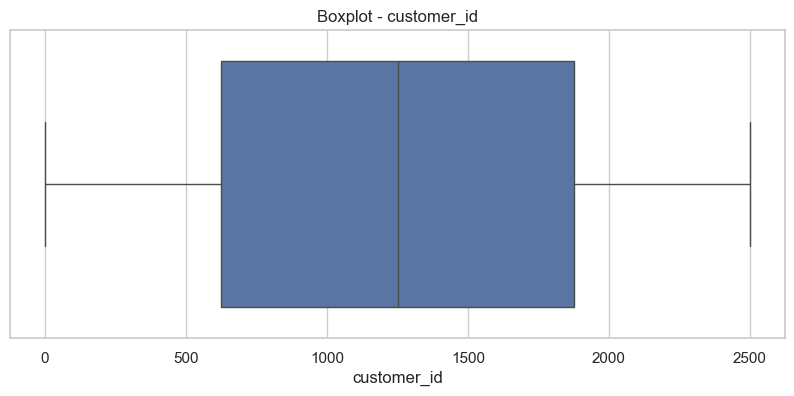

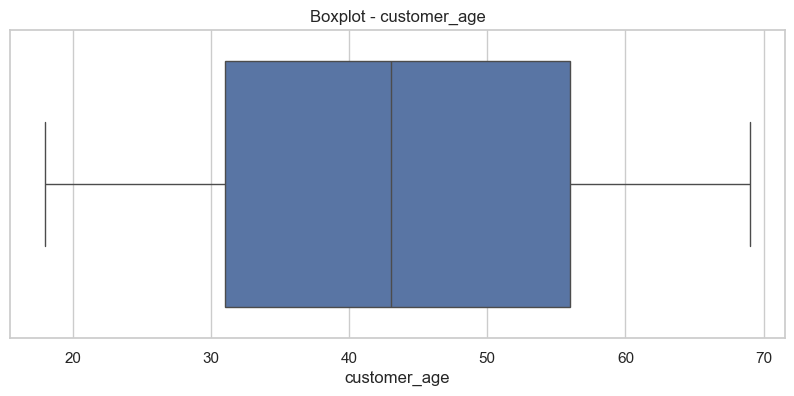

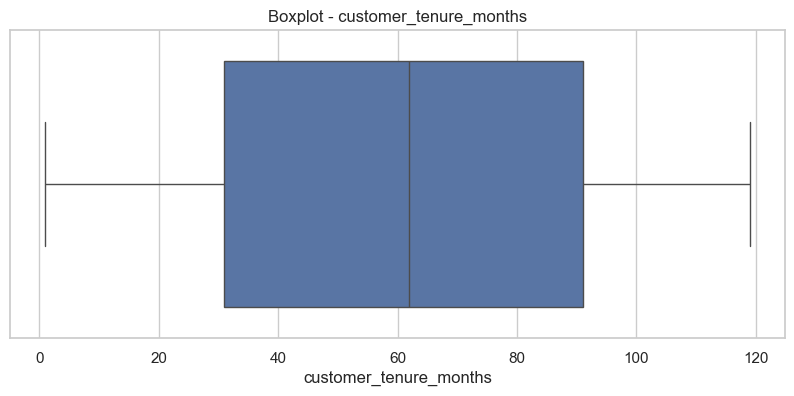

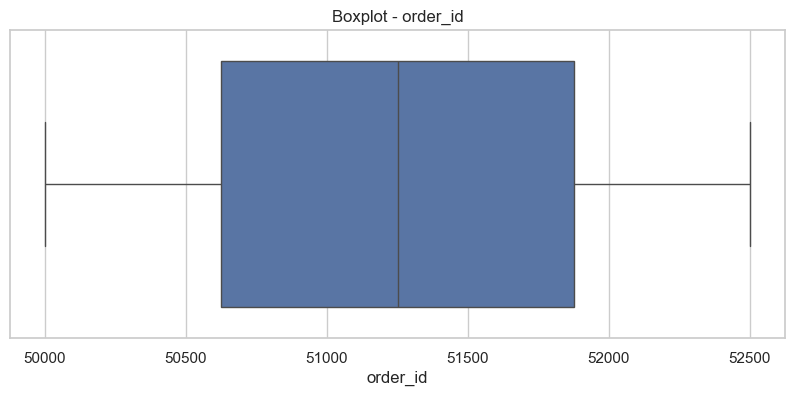

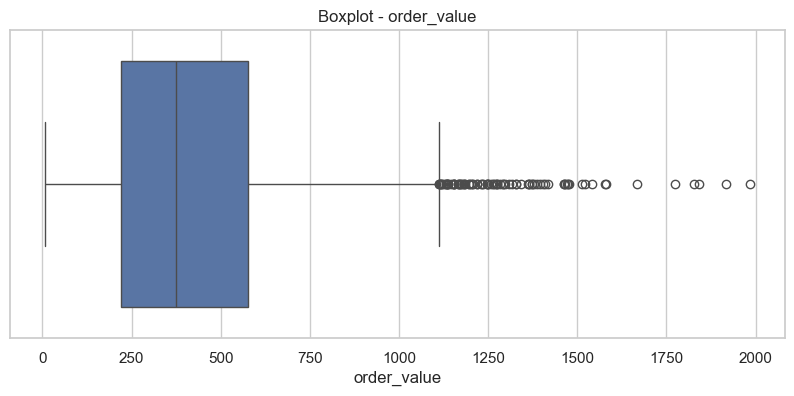

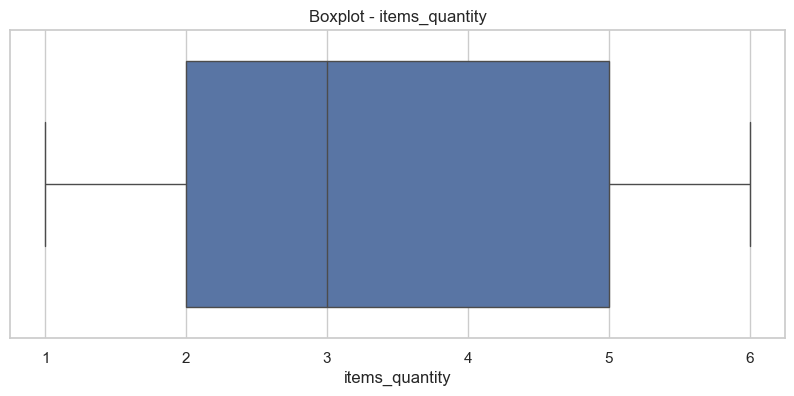

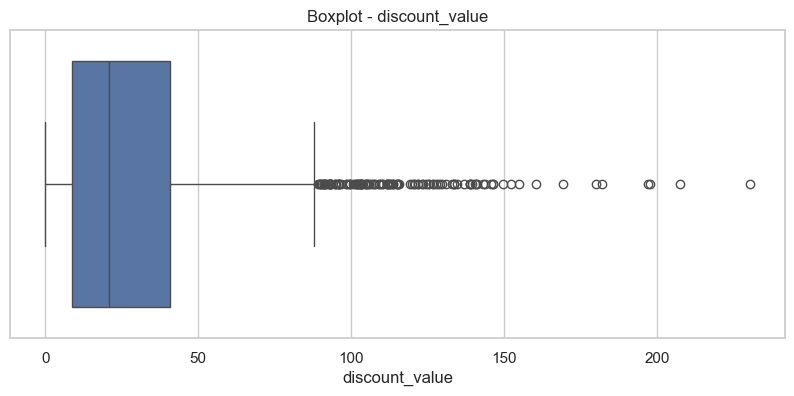

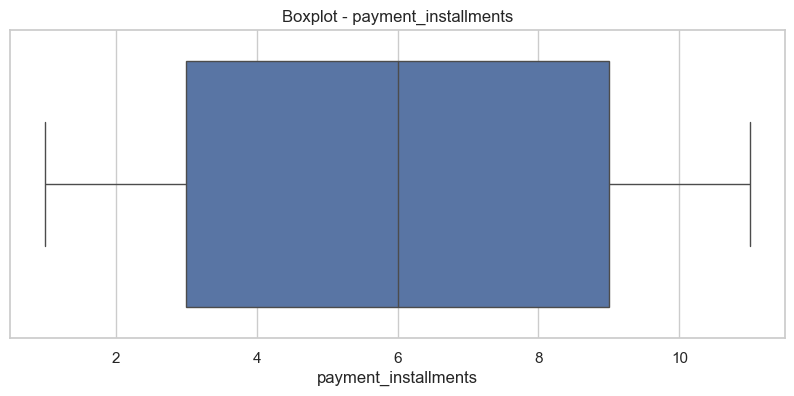

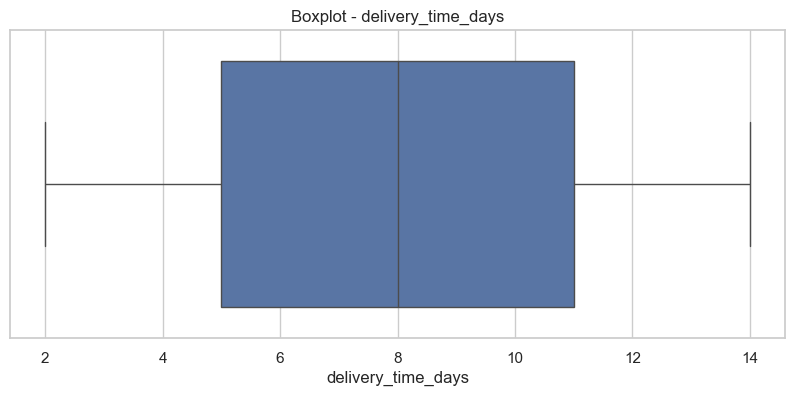

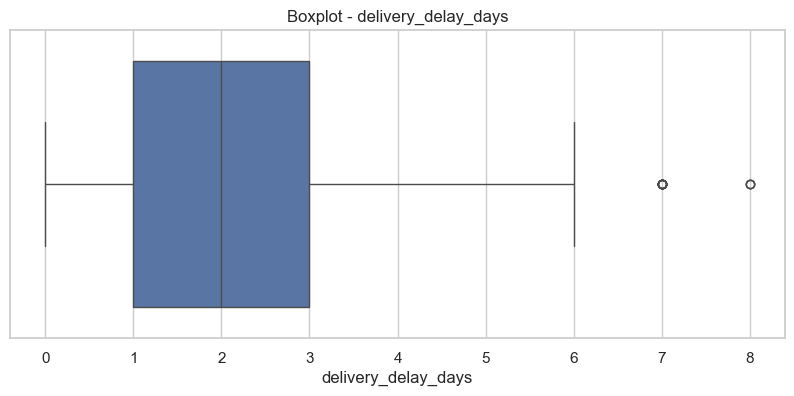

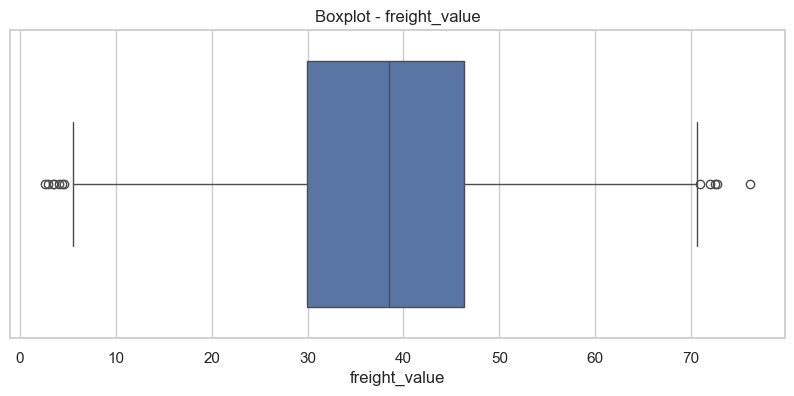

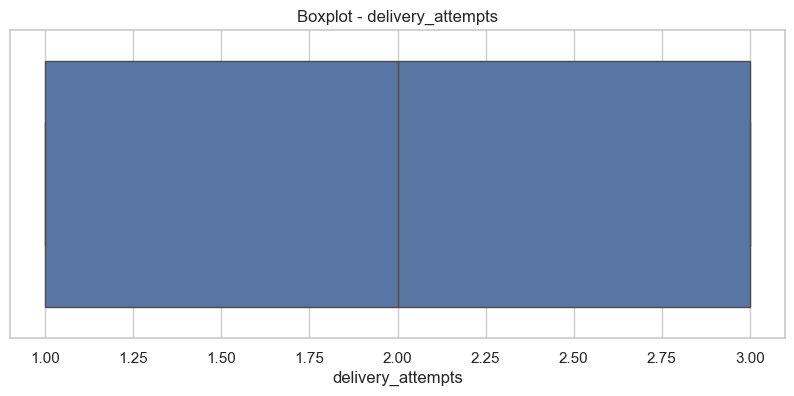

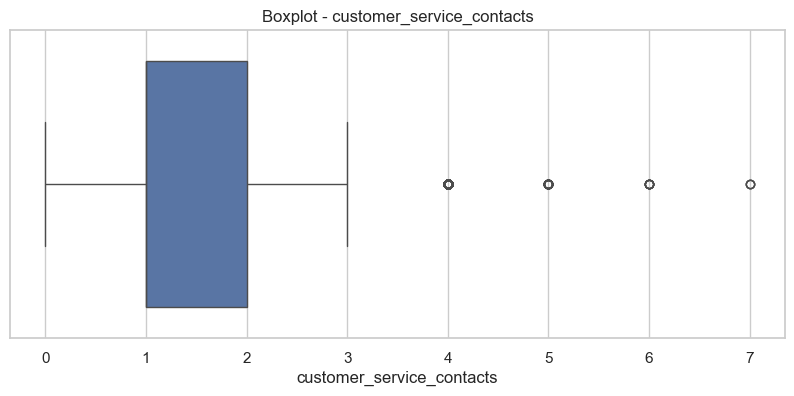

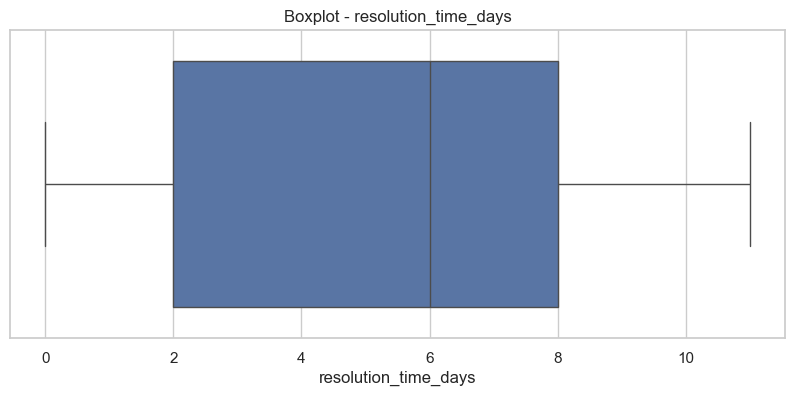

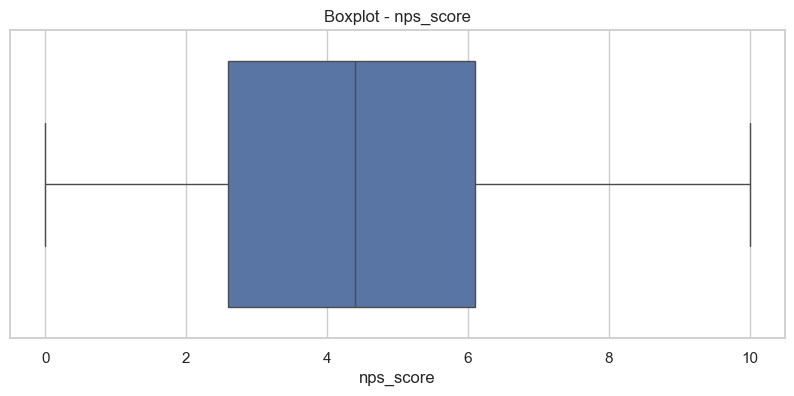

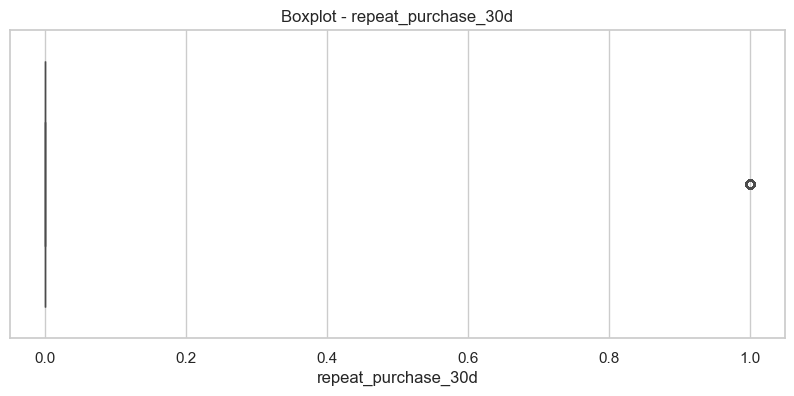

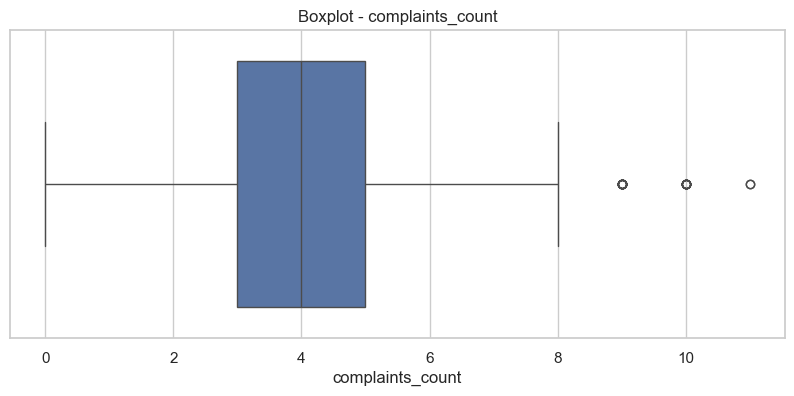

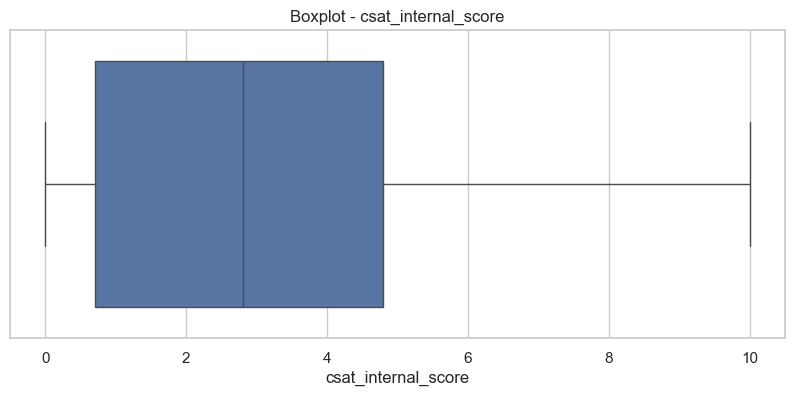

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    plt.figure(figsize=(10,4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot - {col}')

    plt.show()

### DISTRIBUIÇÃO POR REGIÃO ###

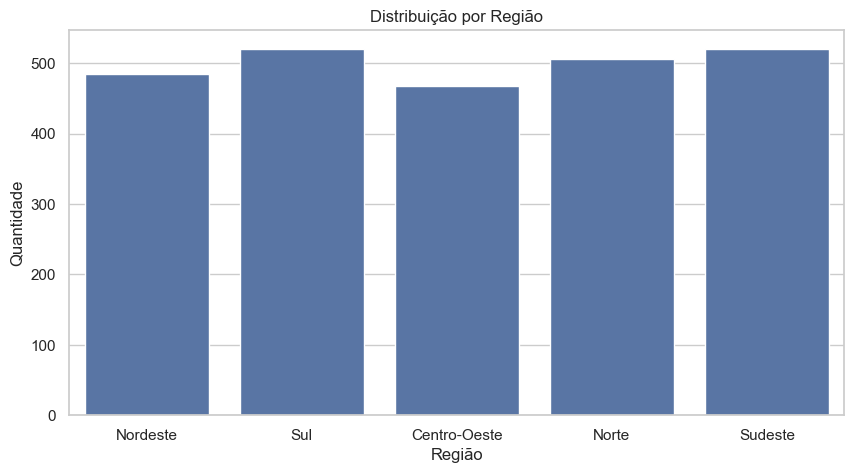

In [13]:
sns.countplot(
    data=df,
    x='customer_region'
)

plt.title('Distribuição por Região')
plt.xlabel('Região')
plt.ylabel('Quantidade')

plt.show()

### CORRELAÇÃO ENTRE VARIÁVEIS ###

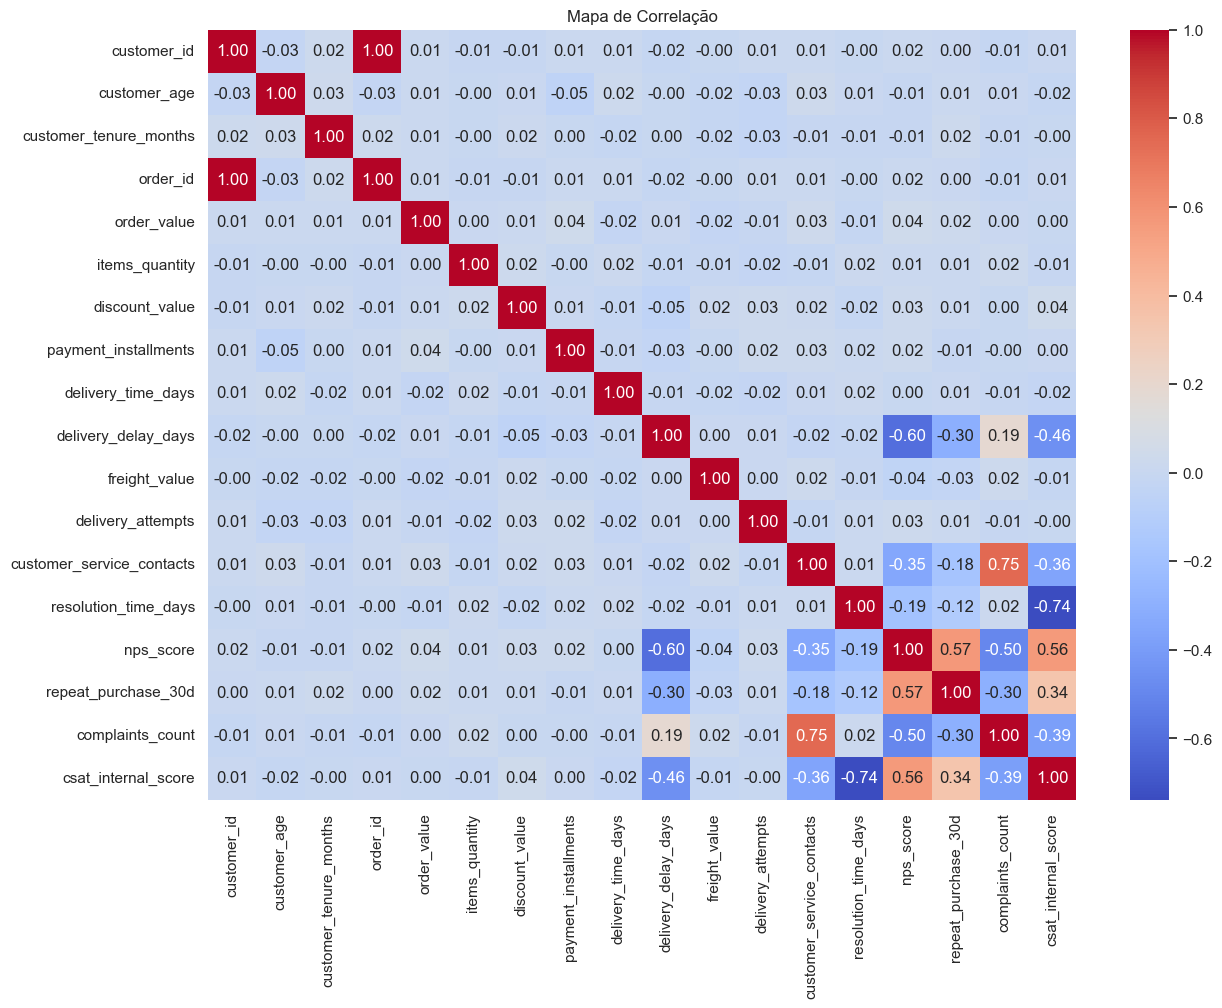

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Mapa de Correlação')

plt.show()


### VARIÁVEIS MAIS RELACIONADAS AO NPS ###

In [15]:
corr_target = corr['nps_score'].sort_values()

print('\nCorrelação com NPS:')
display(corr_target)



Correlação com NPS:


delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
freight_value               -0.041087
customer_age                -0.009936
customer_tenure_months      -0.009711
delivery_time_days           0.000925
items_quantity               0.011468
customer_id                  0.015162
order_id                     0.015162
payment_installments         0.023718
discount_value               0.025104
delivery_attempts            0.027680
order_value                  0.036990
csat_internal_score          0.563952
repeat_purchase_30d          0.570324
nps_score                    1.000000
Name: nps_score, dtype: float64

### ATRASO NA ENTREGA X NPS ###

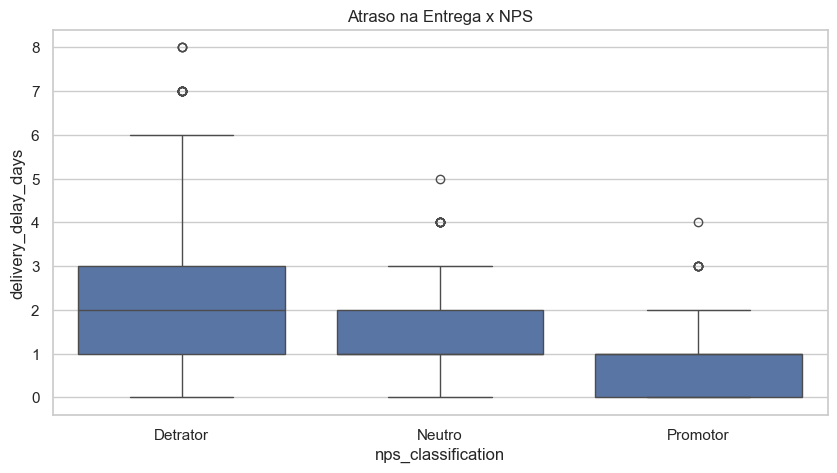


Média de atraso:


nps_classification
Detrator    2.534306
Neutro      1.395089
Promotor    0.756219
Name: delivery_delay_days, dtype: float64

In [16]:
sns.boxplot(
    data=df,
    x='nps_classification',
    y='delivery_delay_days',
    order=['Detrator', 'Neutro', 'Promotor']
)

plt.title('Atraso na Entrega x NPS')

plt.show()

# média de atraso

delay_mean = (
    df.groupby('nps_classification')['delivery_delay_days']
    .mean()
)

print('\nMédia de atraso:')
display(delay_mean)


### CONTATOS NO SUPORTE X NPS ###

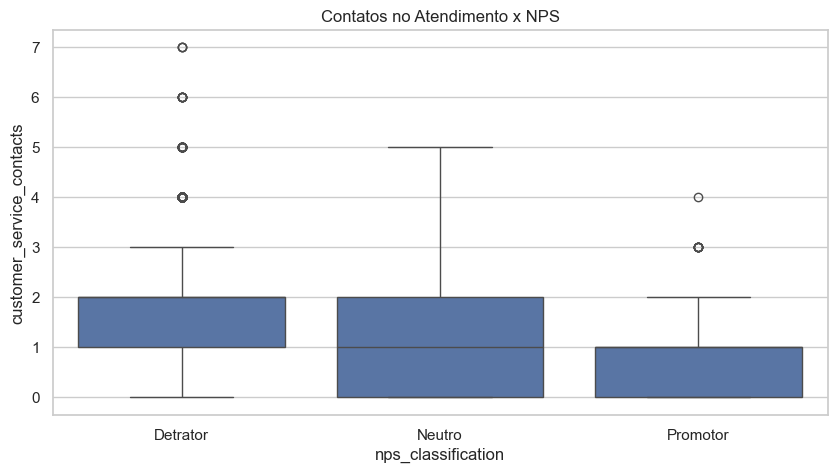


Média de contatos:


nps_classification
Detrator    1.694219
Neutro      1.129464
Promotor    0.781095
Name: customer_service_contacts, dtype: float64

In [17]:
sns.boxplot(
    data=df,
    x='nps_classification',
    y='customer_service_contacts',
    order=['Detrator', 'Neutro', 'Promotor']
)

plt.title('Contatos no Atendimento x NPS')

plt.show()

# média contatos

contacts_mean = (
    df.groupby('nps_classification')['customer_service_contacts']
    .mean()
)

print('\nMédia de contatos:')
display(contacts_mean)


### RECLAMAÇÕES X NPS ###

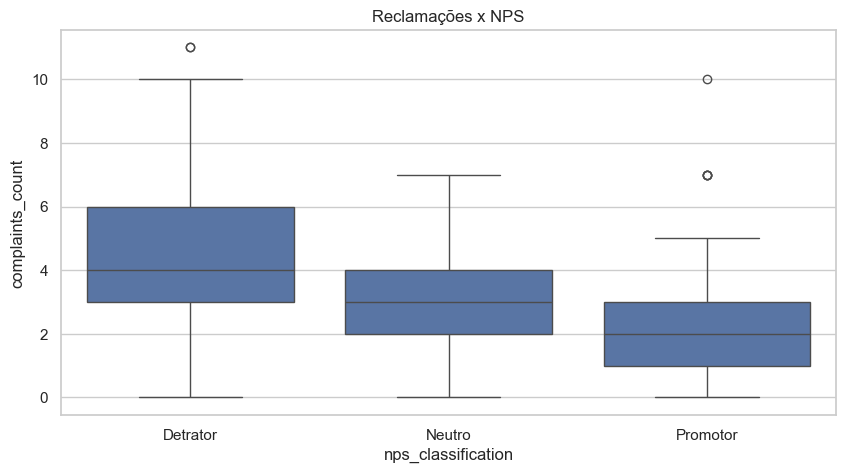


Média de reclamações:


nps_classification
Detrator    4.622907
Neutro      2.986607
Promotor    2.393035
Name: complaints_count, dtype: float64

In [18]:
sns.boxplot(
    data=df,
    x='nps_classification',
    y='complaints_count',
    order=['Detrator', 'Neutro', 'Promotor']
)

plt.title('Reclamações x NPS')

plt.show()

# média reclamações

complaints_mean = (
    df.groupby('nps_classification')['complaints_count']
    .mean()
)

print('\nMédia de reclamações:')
display(complaints_mean)


### TEMPO DE RESOLUÇÃO X NPS ###

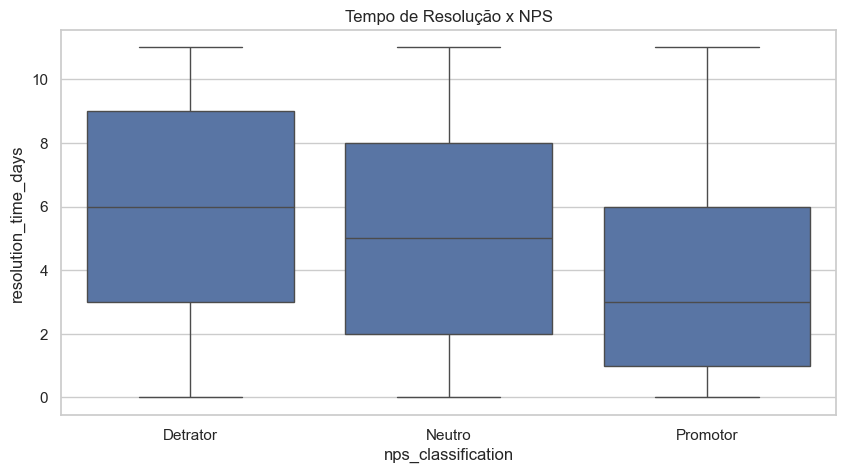


Tempo médio de resolução:


nps_classification
Detrator    5.793625
Neutro      4.832589
Promotor    4.104478
Name: resolution_time_days, dtype: float64

In [19]:
sns.boxplot(
    data=df,
    x='nps_classification',
    y='resolution_time_days',
    order=['Detrator', 'Neutro', 'Promotor']
)

plt.title('Tempo de Resolução x NPS')

plt.show()

# média resolução

resolution_mean = (
    df.groupby('nps_classification')['resolution_time_days']
    .mean()
)

print('\nTempo médio de resolução:')
display(resolution_mean)


### RECOMPRA X NPS ###

repeat_purchase_30d,0,1
nps_classification,,
Detrator,100.000000,0.000000
Neutro,96.205357,3.794643
Promotor,0.000000,100.000000


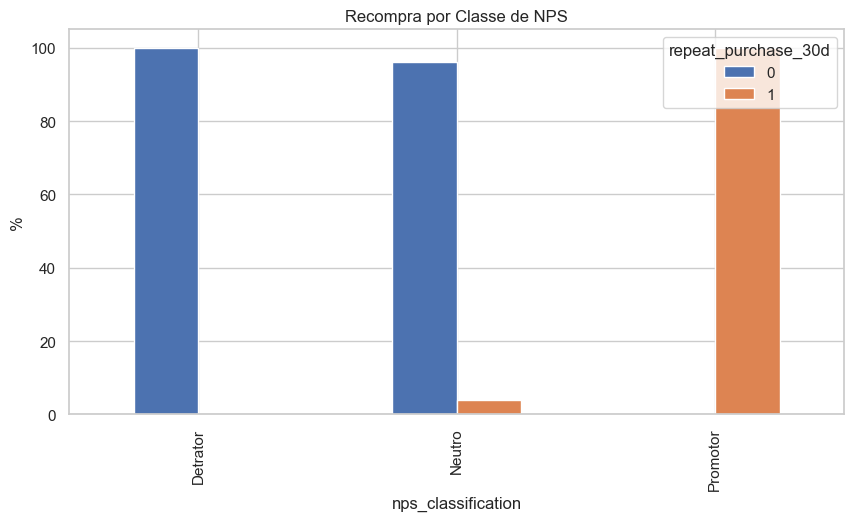

In [20]:

repeat_by_nps = pd.crosstab(
    df['nps_classification'],
    df['repeat_purchase_30d'],
    normalize='index'
) * 100

display(repeat_by_nps)

# gráfico

repeat_by_nps.plot(kind='bar')

plt.title('Recompra por Classe de NPS')
plt.ylabel('%')

plt.show()


### CSAT INTERNO X NPS ###

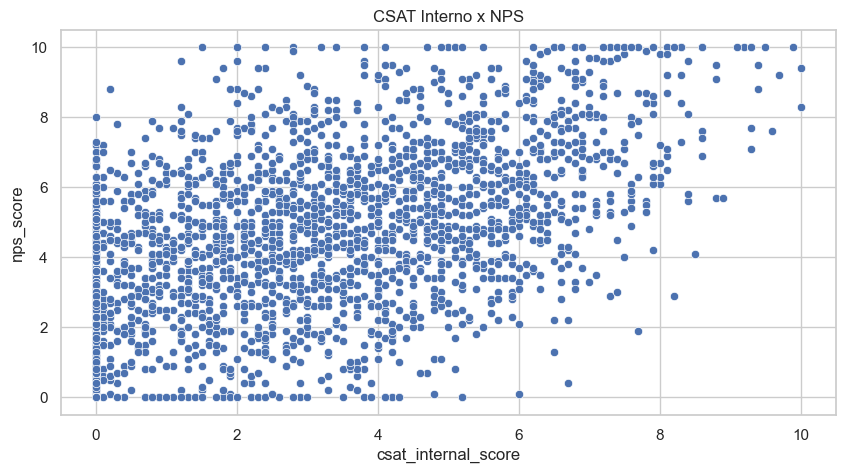


CSAT médio:


nps_classification
Detrator    2.340465
Neutro      4.230357
Promotor    5.604975
Name: csat_internal_score, dtype: float64

In [21]:
sns.scatterplot(
    data=df,
    x='csat_internal_score',
    y='nps_score'
)

plt.title('CSAT Interno x NPS')

plt.show()

# média csat

csat_mean = (
    df.groupby('nps_classification')['csat_internal_score']
    .mean()
)

print('\nCSAT médio:')
display(csat_mean)


### NPS POR REGIÃO ###

customer_region
Centro-Oeste    4.209829
Sudeste         4.373846
Norte           4.382609
Nordeste        4.421649
Sul             4.490979
Name: nps_score, dtype: float64

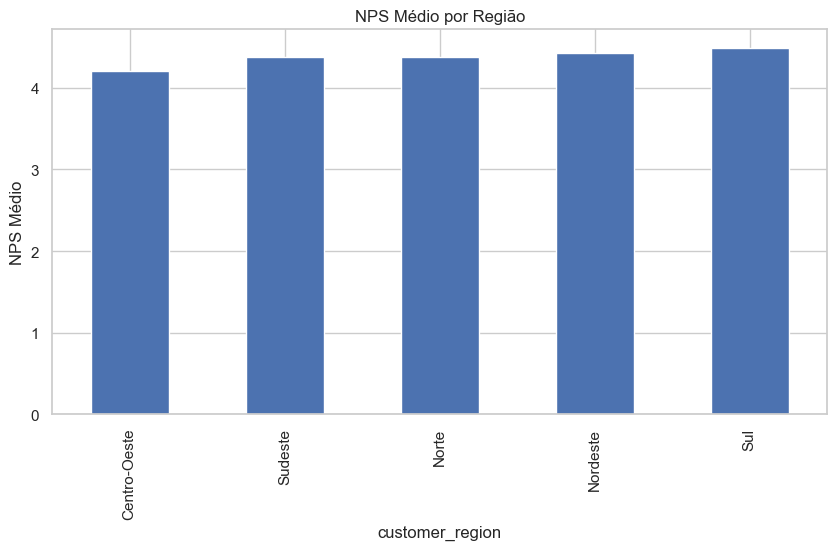

In [22]:
region_nps = (
    df.groupby('customer_region')['nps_score']
    .mean()
    .sort_values()
)

display(region_nps)

# gráfico

region_nps.plot(kind='bar')

plt.title('NPS Médio por Região')
plt.ylabel('NPS Médio')

plt.show()

### TEMPO DE RELACIONAMENTO ###

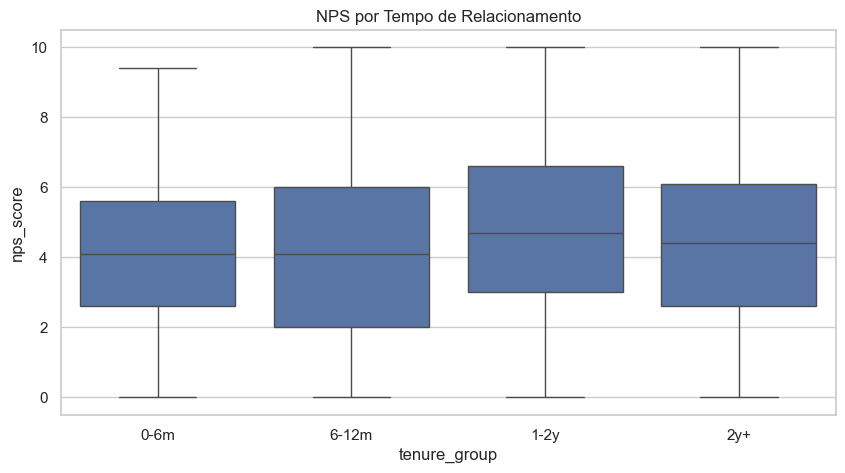

In [23]:
df['tenure_group'] = pd.cut(
    df['customer_tenure_months'],
    bins=[0, 6, 12, 24, 60],
    labels=['0-6m', '6-12m', '1-2y', '2y+']
)

sns.boxplot(
    data=df,
    x='tenure_group',
    y='nps_score'
)

plt.title('NPS por Tempo de Relacionamento')

plt.show()

### CORRELAÇÃO DE PEARSON ###

In [24]:
corr_pearson, p_value = pearsonr(
    df['delivery_delay_days'],
    df['nps_score']
)

print('\nCorrelação de Pearson:')
print(corr_pearson)

print('\nP-valor:')
print(p_value)



Correlação de Pearson:
-0.5972599425164116

P-valor:
1.3144943648022754e-241


### DETECÇÃO DE OUTLIERS ###

In [25]:

Q1 = df['delivery_delay_days'].quantile(0.25)
Q3 = df['delivery_delay_days'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['delivery_delay_days'] < lower) |
    (df['delivery_delay_days'] > upper)
]

print('\nQuantidade de outliers:')
print(outliers.shape)


Quantidade de outliers:
(17, 21)


### PRINCIPAIS INSIGHTS: ###
### Atraso na entrega possui forte impacto negativo no NPS. ###
### Clientes com mais contatos no suporte tendem a ser detratores. ###
### Reclamações aumentam significativamente a insatisfação. ###
### Recompra possui forte relação com clientes promotores. ###
### O CSAT interno acompanha o comportamento do NPS.###
### Melhor eficiência operacional tende a aumentar satisfação e fidelização. ###